# Histogram Analysis and Contrast Enhancement
**Author:** Matheus Leite  
**Date:** May 25, 2025  
This notebook demonstrates how to analyze the brightness distribution of an image using histograms and enhance its contrast using global histogram equalization and CLAHE (Contrast Limited Adaptive Histogram Equalization).


## 1. Import Libraries and Load Image
We start by importing the necessary libraries and loading the input image in grayscale format.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../images/sax.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

## 2. Compute Histogram
We calculate the histogram of the grayscale image to understand how pixel intensities are distributed.


In [4]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

## 3. Plot Histogram
The histogram is plotted using Matplotlib to visualize the brightness distribution. A flat histogram indicates balanced contrast.


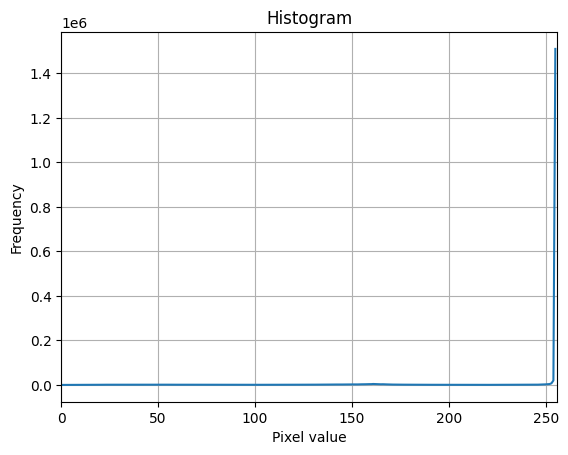

In [5]:
plt.figure()
plt.title("Histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.plot(hist)
plt.xlim([0, 256])
plt.grid()
plt.show()

## 4. Global Histogram Equalization
Using `cv2.equalizeHist`, we stretch the brightness levels across the full 0–255 range to improve global contrast.


In [6]:
equalized = cv2.equalizeHist(gray)

## 5. CLAHE – Adaptive Equalization
Contrast Limited Adaptive Histogram Equalization (CLAHE) enhances local contrast while avoiding noise amplification. It's ideal for images with varying lighting conditions.

In [9]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_equalized = clahe.apply(gray)

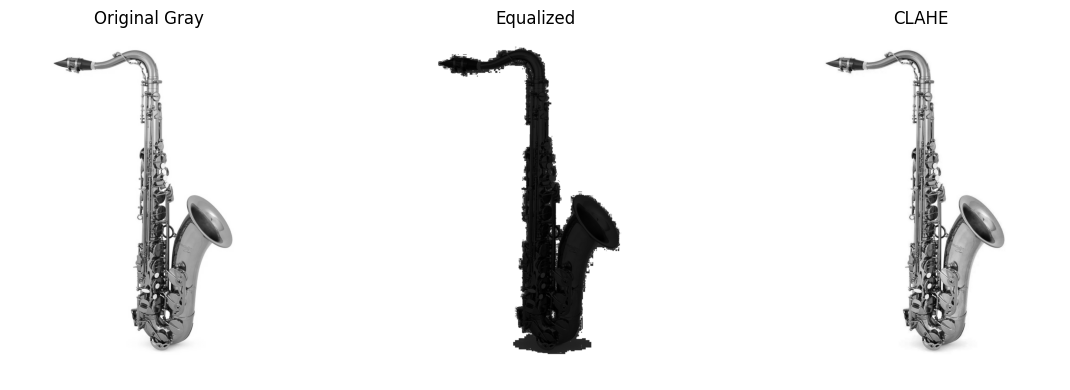

In [10]:
images = [gray, equalized, clahe_equalized]
titles = ["Original Gray", "Equalized", "CLAHE"]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()